In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import geopandas as gpd
import contextily as cx
import zipfile
import mapclassify
import folium
import re

file_path = r"C:\Users\jvkim\OneDrive\Desktop\California-Voting-District-Project"

In [17]:
#Unzip ca_pl2020_official.zip
with zipfile.ZipFile(file_path + r"\Data\ca_pl2020_official.zip") as ca_pl2020:
    ca_pl2020.extractall("Data")
    ca_pl2020.close()

In [18]:
#import data from Data folder
ca_pl94 = pd.read_csv(file_path + r"\Data\state_PL94_2020_Adjusted_P24_DOJ_Block_csv\state_PL94_2020_Adjusted_P24_DOJ_Block.csv")
ca_blocks = gpd.read_file(file_path + r"\Data\tl_2025_06_tabblock20.zip")
ca_votes_2020 = gpd.read_file(file_path + r"\Data\ca_2020_gen_2020_blocks.zip")
ca_votes_2024 = gpd.read_file(file_path + r"\Data\ca_gen_2024_prec.geojson")
ca_2020 = pd.read_csv(file_path + r"\Data\06_CA_CD118.txt")
ca_2025 = pd.read_csv(file_path + r"\Data\ab604.csv")
l2_voter_file = pd.read_csv(file_path + r"\Data\CA_l2_2024_gen_stats_2020block\CA_l2_2024_gen_stats_2020block.csv", dtype={0: str})

In [19]:
#Convert Geoids to ints for joining
ca_blocks["GEOID20"] = ca_blocks["GEOID20"].astype(int)
#Join 2020 and 2025 districts on geoid
ca_blocks_district = ca_blocks.merge(ca_2020, left_on="GEOID20",right_on= "GEOID", how="left")
ca_blocks_district = ca_blocks_district.rename(columns={"CDFP":"2020 District", "COUNTYFP20": "County"})
ca_blocks_district = ca_blocks_district.merge(ca_2025, left_on="GEOID20",right_on= "GEOID", how="left")
ca_blocks_district = ca_blocks_district.drop(["GEOID_x", "GEOID_y", "STATEFP20"], axis=1)
ca_blocks_district = ca_blocks_district.rename(columns={"CDFP":"2025 District"})

#Join with PL 94-171 for demographic data 
ca_block_demo = ca_blocks_district.merge(ca_pl94, left_on="GEOID20",right_on= "BLOCK20", how="left")

#Filter l2 voter file to remove "NO BLOCK" rows and merge on geoid
l2_voter_file_filtered = l2_voter_file[~(l2_voter_file["geoid20"].str.contains("NO BLOCK", regex = False))]
l2_voter_file_filtered["geoid20"] = l2_voter_file_filtered["geoid20"].astype(int)
l2_voter_file_no_block = l2_voter_file[(l2_voter_file["geoid20"].str.contains("NO BLOCK", regex = False))]
ca_l2 = ca_block_demo.merge(l2_voter_file_filtered, left_on="GEOID20",right_on= "geoid20", how="left")
 
#Merge 2020 General Election Data
ca_votes_2020["GEOID20"] = ca_votes_2020["GEOID20"].astype(int)
ca_votes_2020 = ca_votes_2020.drop(["geometry"], axis=1)
ca = ca_block_demo.merge(ca_votes_2020, left_on="GEOID20",right_on= "GEOID20", how="left")
ca_filtered = ca[ca["Population P2"]>0]

C:\Users\jvkim\AppData\Local\Temp\ipykernel_21244\2850471774.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l2_voter_file_filtered["geoid20"] = l2_voter_file_filtered["geoid20"].astype(int)


# Hispanic Population Analysis

The function below allows one to compare the distribution of "Hispanic Origin" people in a given district between the prior 2020 map and the new map under Proposition 50

Total populations: Prior: 760066, Prop 50: 760065
Hispanic populations: Prior: 202409, Prop 50: 176798


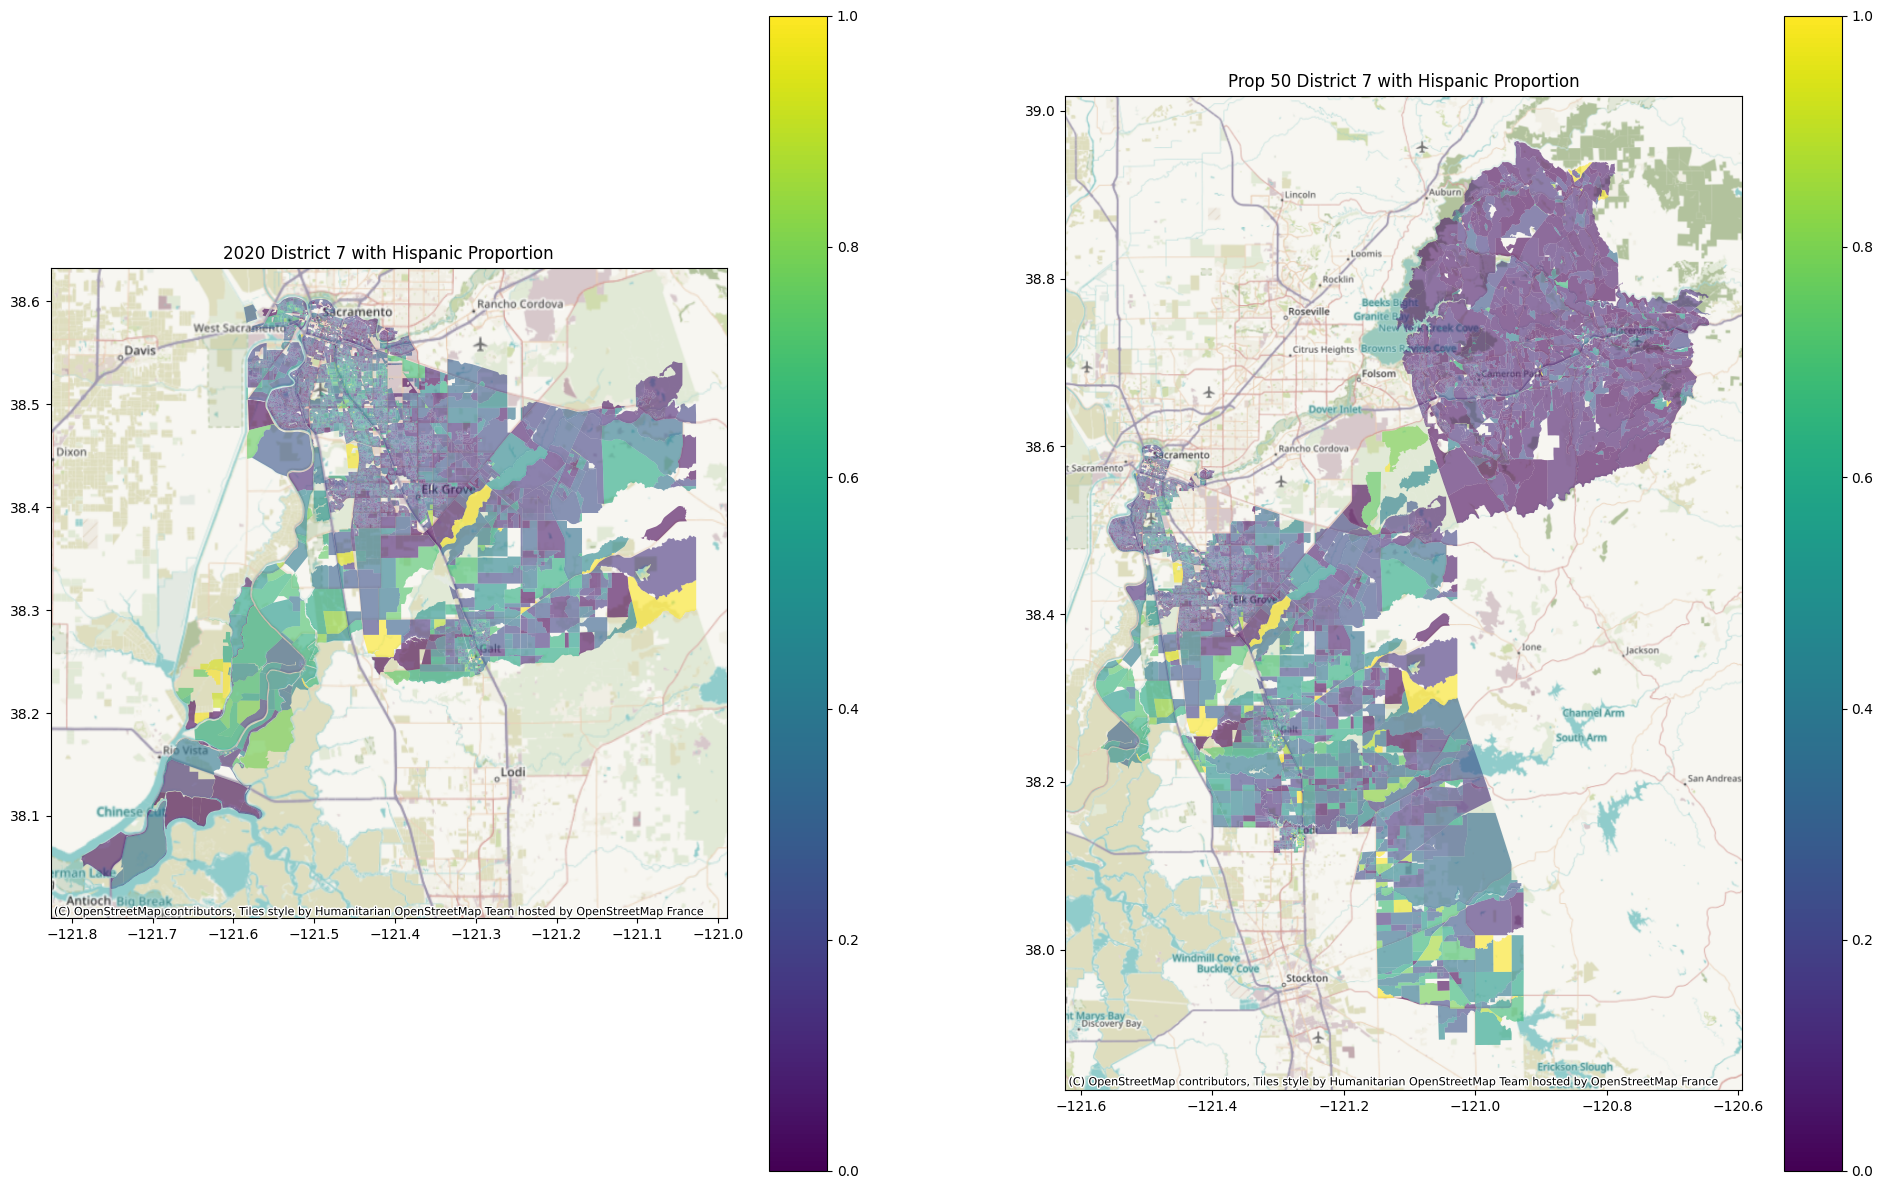

In [20]:
def district_compare(district, proportion = True):
    assert (district > 0 and district<=52), "Invalid district number"
    hispanic_2020_unfiltered = ca[["GEOID20", "geometry", "Population P2", "Hispanic Origin","2020 District", "County"]][ca["2020 District"] == district]
    hispanic_2020 = ca_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin","2020 District", "County"]][ca_filtered["2020 District"] == district]
    hispanic_2020["Hispanic Proportion"] = hispanic_2020["Hispanic Origin"] / hispanic_2020["Population P2"]
    hispanic_2025_unfiltered = ca[["GEOID20", "geometry", "Population P2", "Hispanic Origin", "2025 District", "County"]][ca["2025 District"] == district]
    hispanic_2025 = ca_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin", "2025 District", "County"]][ca_filtered["2025 District"] == district]
    hispanic_2025["Hispanic Proportion"] = hispanic_2025["Hispanic Origin"] / hispanic_2025["Population P2"]

    print(f"Total populations: Prior: {sum(hispanic_2020["Population P2"])}, Prop 50: {sum(hispanic_2025["Population P2"])}")
    print(f"Hispanic populations: Prior: {sum(hispanic_2020["Hispanic Origin"])}, Prop 50: {sum(hispanic_2025["Hispanic Origin"])}")

    fig, axs = plt.subplots(ncols=2,nrows=1, figsize=(24, 15))

    if proportion:
        hispanic_2020.plot("Hispanic Proportion", legend=True, ax=axs[0], alpha = 0.6)
        #hispanic_2020_unfiltered.plot(facecolor="none", edgecolor="black", ax=axs[0], linewidth = 0.1)
        cx.add_basemap(crs=hispanic_2020.crs, ax = axs[0])
        axs[0].set_title(f"2020 District {district} with Hispanic Proportion")

        hispanic_2025.plot("Hispanic Proportion", legend=True, ax=axs[1], alpha = 0.6)
        cx.add_basemap(crs=hispanic_2025.crs, ax = axs[1])
        axs[1].set_title(f"Prop 50 District {district} with Hispanic Proportion")
    else:
        hispanic_2020.plot("Hispanic Origin", legend=True, ax=axs[0], alpha = 0.6)
        cx.add_basemap(crs=hispanic_2020.crs, ax = axs[0])
        axs[0].set_title(f"2020 District {district} with Hispanic Population")

        hispanic_2025.plot("Hispanic Origin", legend=True, ax=axs[1], alpha = 0.6)
        cx.add_basemap(crs=hispanic_2025.crs, ax = axs[1])
        axs[1].set_title(f"Prop 50 District {district} with Hispanic Population")

district_compare(7, proportion=True)

In [21]:
#Combines California demographic information by Congressional District
ca_2020 = ca[["geometry", "Population P2", "Hispanic Origin","2020 District", "G20PREDBID", "G20PRERTRU", "G20PRELJOR", "G20PREGHAW", "G20PREAFUE", "G20PREPLAR"]].dissolve(by="2020 District",aggfunc='sum')
ca_2025 = ca[["geometry", "Population P2", "Hispanic Origin","2025 District", "G20PREDBID", "G20PRERTRU", "G20PRELJOR", "G20PREGHAW", "G20PREAFUE", "G20PREPLAR"]].dissolve(by="2025 District",aggfunc='sum')

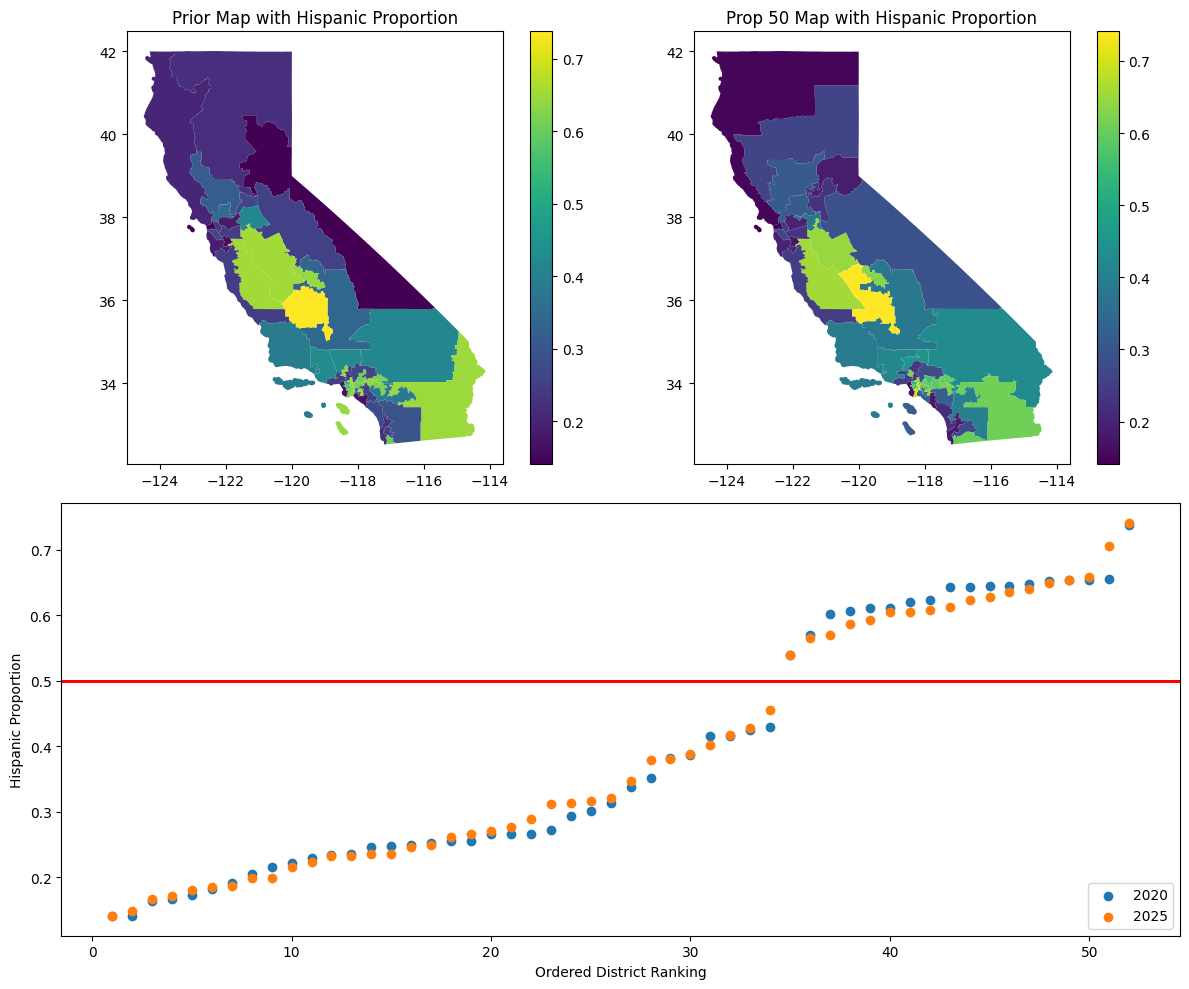

In [22]:
hispanic_district_demo_2020 = ca_2020.copy()
hispanic_district_demo_2020["Hispanic Proportion"] = hispanic_district_demo_2020["Hispanic Origin"] / hispanic_district_demo_2020["Population P2"]
hispanic_district_demo_2025 = ca_2025.copy()
hispanic_district_demo_2025["Hispanic Proportion"] = hispanic_district_demo_2025["Hispanic Origin"] / hispanic_district_demo_2025["Population P2"]

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(ncols=2, nrows=2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

#2020 Districts
hispanic_district_demo_2020.plot("Hispanic Proportion", legend=True, ax=ax1) 
ax1.set_title("Prior Map with Hispanic Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=hispanic_district_demo_2020["Hispanic Proportion"].sort_values(), label = "2020")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Hispanic Proportion")

#2025 Districts
hispanic_district_demo_2025.plot("Hispanic Proportion", legend=True, ax=ax2) 
ax2.set_title("Prop 50 Map with Hispanic Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=hispanic_district_demo_2025["Hispanic Proportion"].sort_values(), label = "2025")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Hispanic Proportion")
ax3.legend(loc="lower right")

plt.tight_layout()

Majority Hispanic Congressional districts. Consistent with list given by https://en.wikipedia.org/wiki/List_of_majority-minority_United_States_congressional_districts#Hispanic_and_Latino

(Note: Percentages on Wikipedia are for voting age population, and thus will different to the proportion listed below)

In [23]:
hispanic_district_demo_2020[hispanic_district_demo_2020["Hispanic Proportion"]>0.5].drop("geometry", axis=1)

,Population P2,Hispanic Origin,G20PREDBID,G20PRERTRU,G20PRELJOR,G20PREGHAW,G20PREAFUE,G20PREPLAR,Hispanic Proportion
2020 District,,,,,,,,,
13,760065,497280,125257.68,100236.78,2281.37,906.79,1002.56,1031.12,0.654260
18,760065,497849,190094.37,72014.84,2708.45,1138.25,960.37,997.81,0.655008
21,760065,488680,133844.17,87865.95,2275.44,911.12,849.55,642.68,0.642945
22,760067,560774,103954.25,79682.21,1821.18,705.30,986.39,996.21,0.737795
25,760066,492481,150335.09,109719.24,2182.75,950.09,1047.21,1012.99,0.647945
29,760066,488578,204900.06,63872.91,1929.94,1512.51,1223.30,1428.73,0.642810
31,760066,460464,198002.45,102698.48,2629.96,1483.15,1044.93,1207.78,0.605821
33,760067,470902,168258.25,98993.23,2547.84,1308.97,1197.10,1140.19,0.619553
34,760067,497280,205073.91,42316.64,1442.17,1871.09,1025.46,1600.10,0.654258


# Partisan Analysis

The maps below show the partisanship for each Congressional district for both the original 2020 districts and the districts laid out in Proposition 50. The partisanship of districts is calculated by dividing the votes cast for Biden in the 2020 Presidential election divided by the total number of votes cast for both Trump and Biden (2 party vote share). The graph below directly compares the partisanship of the two maps, displaying the Democrat 2 party vote share on the vertical axis. Districts are plotted in order of lowest to highest Democrat vote share

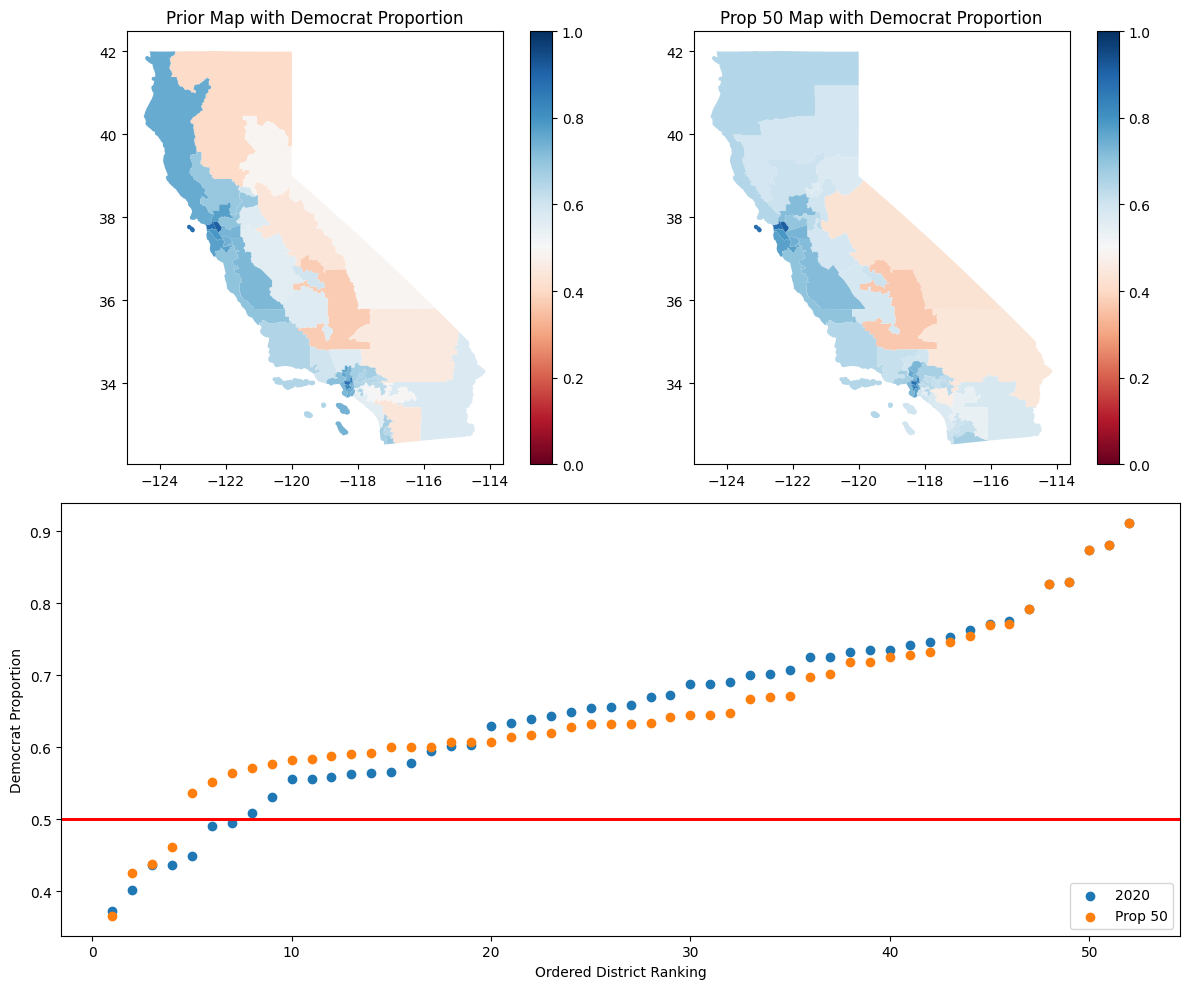

In [24]:
voter_2020 = ca_2020.copy()
voter_2020["Total Voters"] = voter_2020["G20PREDBID"] + voter_2020["G20PRERTRU"] #+ voter_2020["G20PRELJOR"] + voter_2020["G20PREGHAW"] + voter_2020["G20PREAFUE"] + voter_2020["G20PREPLAR"]
voter_2020["Democrat Proportion"] = voter_2020["G20PREDBID"] / voter_2020["Total Voters"]
voter_2025 = ca_2025.copy()
voter_2025["Total Voters"] = voter_2025["G20PREDBID"] + voter_2025["G20PRERTRU"] #+ voter_2025["G20PRELJOR"] + voter_2025["G20PREGHAW"] + voter_2025["G20PREAFUE"] + voter_2025["G20PREPLAR"]
voter_2025["Democrat Proportion"] = voter_2025["G20PREDBID"] / voter_2025["Total Voters"]

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(ncols=2, nrows=2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

#2020 Districts
voter_2020.plot("Democrat Proportion", cmap="RdBu", ax=ax1, figsize=(12, 12), legend=True, vmin=0, vmax=1)
ax1.set_title("Prior Map with Democrat Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=voter_2020["Democrat Proportion"].sort_values(), label = "2020")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Democrat Proportion")

#2025 Districts
voter_2025.plot("Democrat Proportion", cmap="RdBu", ax=ax2, figsize=(12, 12), legend=True, vmin=0, vmax=1)
ax2.set_title("Prop 50 Map with Democrat Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=voter_2025["Democrat Proportion"].sort_values(), label = "Prop 50")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Democrat Proportion")
ax3.legend(loc="lower right")

plt.tight_layout()

The L2 dataset shows a similar trend, though the shown prior map partisanship and effect of Prop 50 on Congressional seats aligns better with reporting such as https://www.bbc.com/news/articles/c1lqr30l246o.

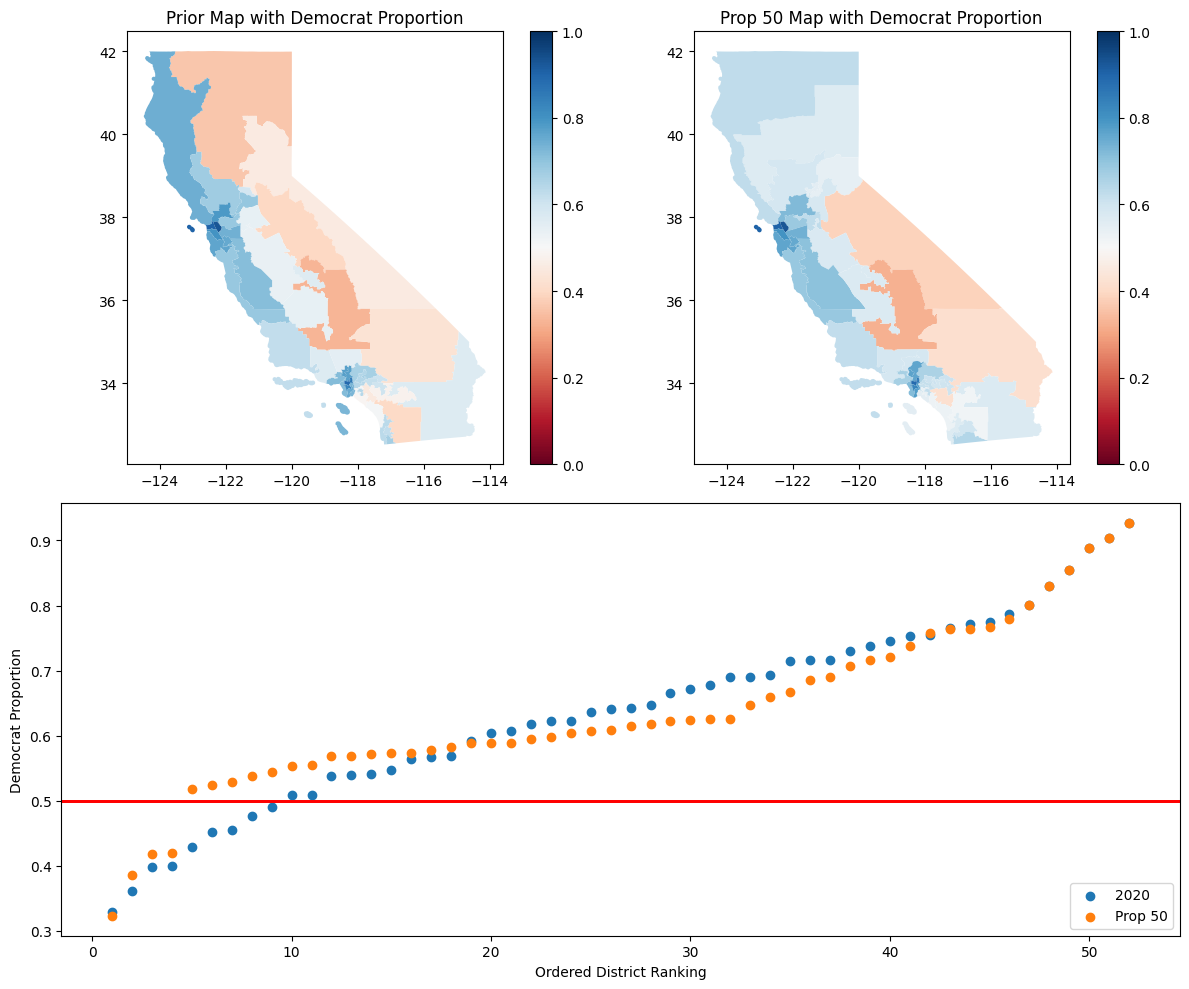

In [27]:
#Combines California demographic information by Congressional District
ca_2020_l2 = ca_l2[["geometry","2020 District", "voted_all", "voted_party_democratic", "voted_party_republican"]].dissolve(by="2020 District",aggfunc='sum')
ca_2025_l2 = ca_l2[["geometry","2025 District", "voted_all", "voted_party_democratic", "voted_party_republican"]].dissolve(by="2025 District",aggfunc='sum')

ca_2020_l2["2-Party Total"] = ca_2020_l2["voted_party_democratic"] + ca_2020_l2["voted_party_republican"]
ca_2025_l2["2-Party Total"] = ca_2025_l2["voted_party_democratic"] + ca_2025_l2["voted_party_republican"]
ca_2020_l2["Democrat Proportion"] = ca_2020_l2["voted_party_democratic"] / ca_2020_l2["2-Party Total"]
ca_2025_l2["Democrat Proportion"] = ca_2025_l2["voted_party_democratic"] / ca_2025_l2["2-Party Total"]

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(ncols=2, nrows=2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

#2020 Districts
ca_2020_l2.plot("Democrat Proportion", cmap="RdBu", ax=ax1, figsize=(12, 12), legend=True, vmin=0, vmax=1)
ax1.set_title("Prior Map with Democrat Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=ca_2020_l2["Democrat Proportion"].sort_values(), label = "2020")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Democrat Proportion")

#2025 Districts
ca_2025_l2.plot("Democrat Proportion", cmap="RdBu", ax=ax2, figsize=(12, 12), legend=True, vmin=0, vmax=1)
ax2.set_title("Prop 50 Map with Democrat Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=ca_2025_l2["Democrat Proportion"].sort_values(), label = "Prop 50")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Democrat Proportion")
ax3.legend(loc="lower right")

plt.tight_layout()